# **Building and Evaluating an SVM Model for Diabetes Prediction**

**Student: MANH QUYNH**

In [4]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [5]:
df = pd.read_csv(
    r"C:/Users/MANH QUYNH/Downloads/diabetes_prediction_dataset.csv/diabetes_prediction_dataset.csv"
)

print(df.head())
print(df.columns)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')


In [ ]:
#Kiểm tra dữ liệu
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

C:\Users\MANH QUYNH\AppData\Local\Temp\ipykernel_21468\1772694881.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="diabetes", palette="Set2")


Text(0, 0.5, 'Số lượng')

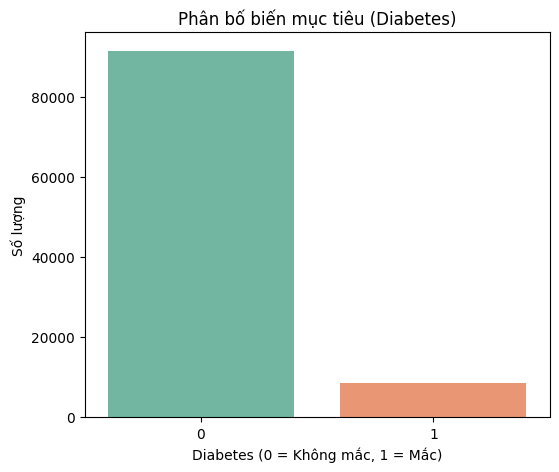

In [ ]:

# Xem phân bố biến mục tiêu

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="diabetes", palette="Set2")

plt.title("Phân bố biến mục tiêu (Diabetes)")
plt.xlabel("Diabetes (0 = Không mắc, 1 = Mắc)")
plt.ylabel("Số lượng")
# Hiển thị số lượng trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11)

plt.show()

In [12]:
print("Số lượng từng lớp:")
print(df["diabetes"].value_counts())

print("\nTỷ lệ (%):")
print(round(df["diabetes"].value_counts(normalize=True) * 100, 2))

Số lượng từng lớp:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Tỷ lệ (%):
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


In [13]:
#Tách biến độc lập và phụ thuộc
X = df.drop("diabetes", axis=1)

y = df["diabetes"]

In [ ]:
#Chia dữ liệu Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print(df.dtypes)

gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [ ]:

# Mã hóa các biến phân loại
df = pd.get_dummies(
    df,
    columns=["gender", "smoking_history"],
    drop_first=True,
    dtype=int
)

In [18]:
print(df.dtypes)

age                            float64
hypertension                     int64
heart_disease                    int64
bmi                            float64
HbA1c_level                    float64
blood_glucose_level              int64
diabetes                         int64
gender_Male                      int64
gender_Other                     int64
smoking_history_current          int64
smoking_history_ever             int64
smoking_history_former           int64
smoking_history_never            int64
smoking_history_not current      int64
dtype: object


In [19]:
#TÁCH DỮ LIỆU
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [20]:
#Chia Train/Test SAU KHI TÁCH DỮ LIỆU
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Huấn luyện mô hình SVM
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
#Chuẩn hóa
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
#DỰ ĐOÁN 
y_pred = svm_model.predict(X_test)

In [25]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy,4))

Accuracy: 0.8962


In [27]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18300
           1       0.45      0.91      0.60      1700

    accuracy                           0.90     20000
   macro avg       0.72      0.90      0.77     20000
weighted avg       0.94      0.90      0.91     20000



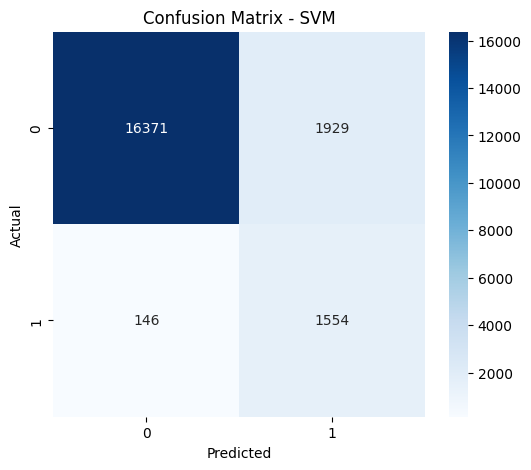

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

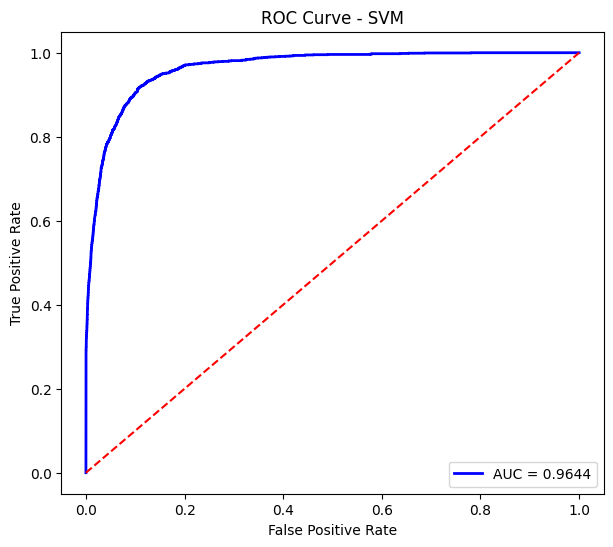

AUC = 0.9644


In [29]:
#ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

# Xác suất dự đoán
y_prob = svm_model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         color="blue",
         linewidth=2,
         label=f"AUC = {auc:.4f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc="lower right")

plt.show()

print("AUC =", round(auc,4))

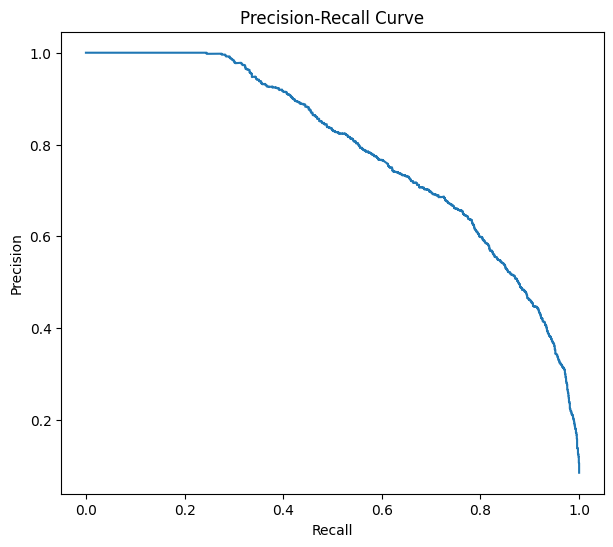

In [30]:
#Precision - Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [31]:
#Đánh giá bằng Cohen's Kappa
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, y_pred)

print("Cohen's Kappa =", round(kappa,4))

Cohen's Kappa = 0.548


In [33]:
#Tính chỉ số F1-score
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-score =", round(f1,4))

F1-score = 0.5997


In [34]:
#MCC (Matthews Correlation Coefficient)
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test,y_pred)

print("MCC =",mcc)

MCC = 0.5947018941457769


In [35]:
#Tổng hợp các chỉ số
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    cohen_kappa_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred),4))
print("Recall   :", round(recall_score(y_test, y_pred),4))
print("F1-score :", round(f1_score(y_test, y_pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob),4))
print("Kappa    :", round(cohen_kappa_score(y_test, y_pred),4))

Accuracy : 0.8962
Precision: 0.4462
Recall   : 0.9141
F1-score : 0.5997
ROC-AUC  : 0.9644
Kappa    : 0.548


# **Exploratory Data Analysis - EDA**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(
    r"C:/Users/MANH QUYNH/Downloads/diabetes_prediction_dataset.csv/diabetes_prediction_dataset.csv"
)

print(df.head())
print(df.columns)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')


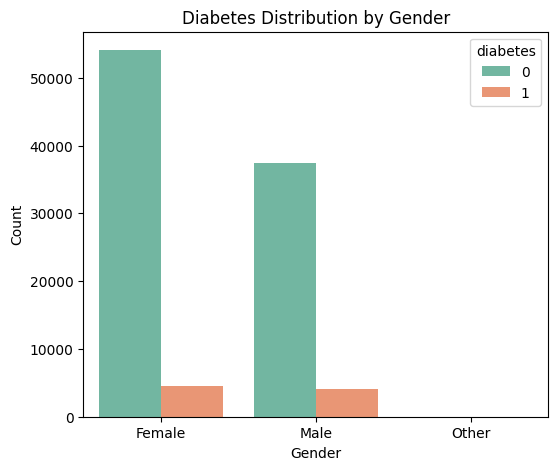

In [6]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='gender',
    hue='diabetes',
    palette='Set2'
)

plt.title("Diabetes Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

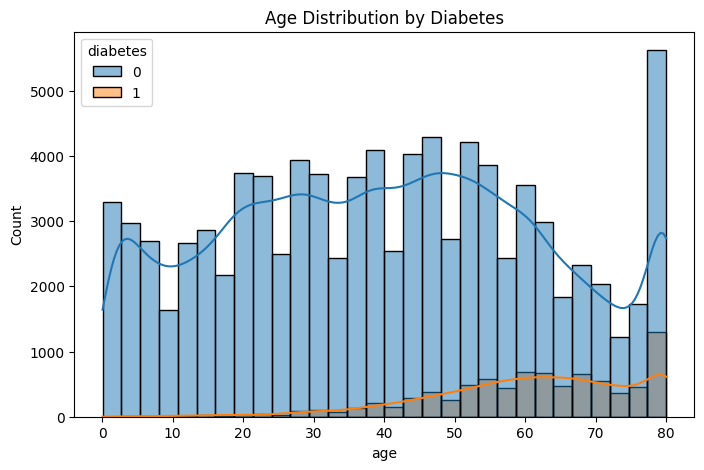

In [7]:
#Phân bố theo độ tuổi
plt.figure(figsize=(8,5))

sns.histplot(data=df,
             x='age',
             hue='diabetes',
             bins=30,
             kde=True)

plt.title("Age Distribution by Diabetes")

plt.show()

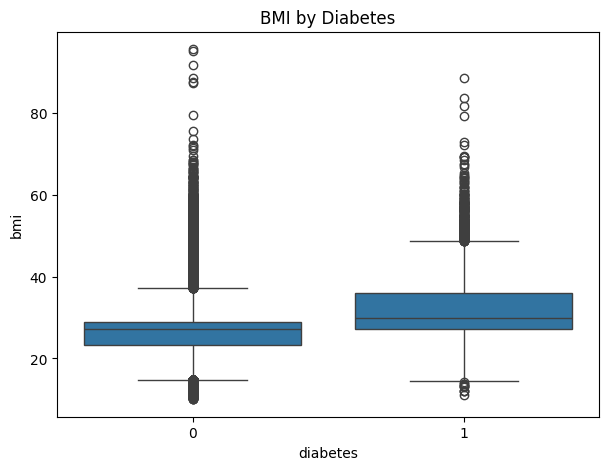

In [9]:
#BMI và Diabetes
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='diabetes',
    y='bmi'
)

plt.title("BMI by Diabetes")

plt.show()

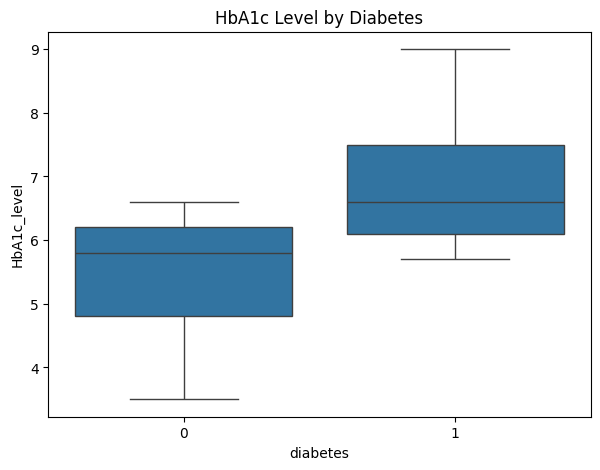

In [11]:
#HbA1c và Diabetes
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='diabetes',
    y='HbA1c_level'
)

plt.title("HbA1c Level by Diabetes")

plt.show()

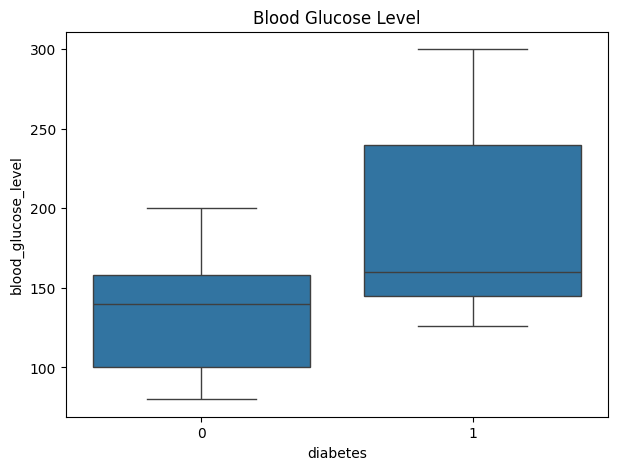

In [12]:
#Blood Glucose và Diabetes
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='diabetes',
    y='blood_glucose_level'
)

plt.title("Blood Glucose Level")

plt.show()

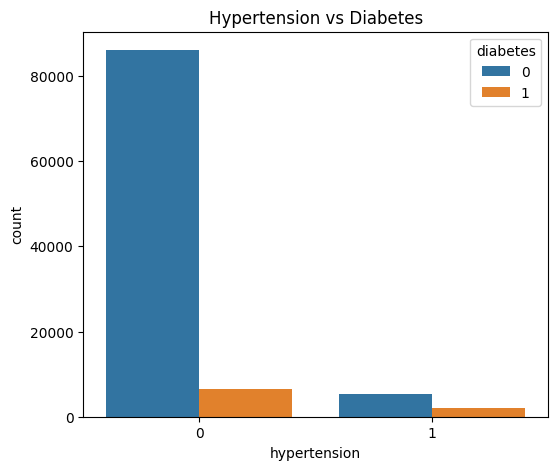

In [13]:
#Hypertension
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='hypertension',
    hue='diabetes'
)

plt.title("Hypertension vs Diabetes")

plt.show()

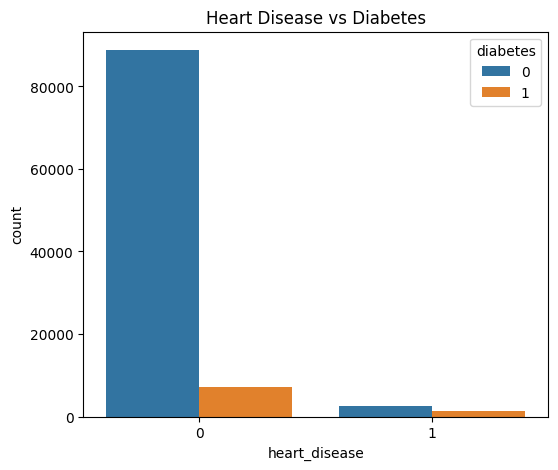

In [15]:
#Heart Disease
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='heart_disease',
    hue='diabetes'
)

plt.title("Heart Disease vs Diabetes")

plt.show()

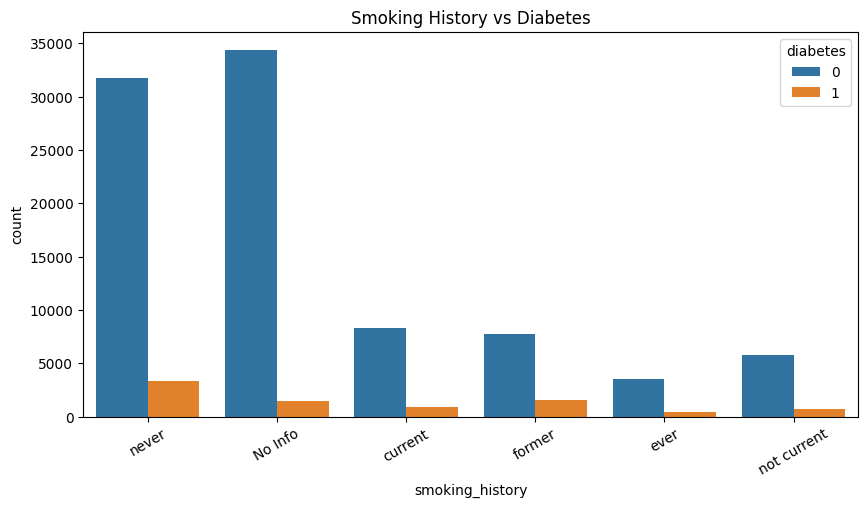

In [16]:
#Smoking History
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='smoking_history',
    hue='diabetes'
)

plt.xticks(rotation=30)

plt.title("Smoking History vs Diabetes")

plt.show()


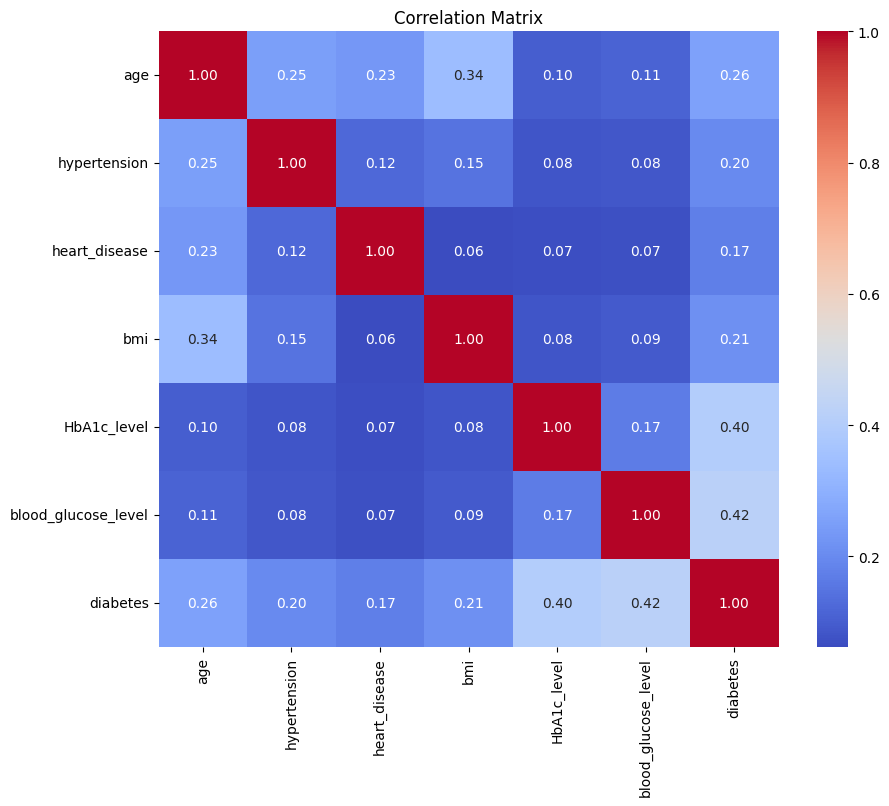

In [17]:
#Heatmap tương quan
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

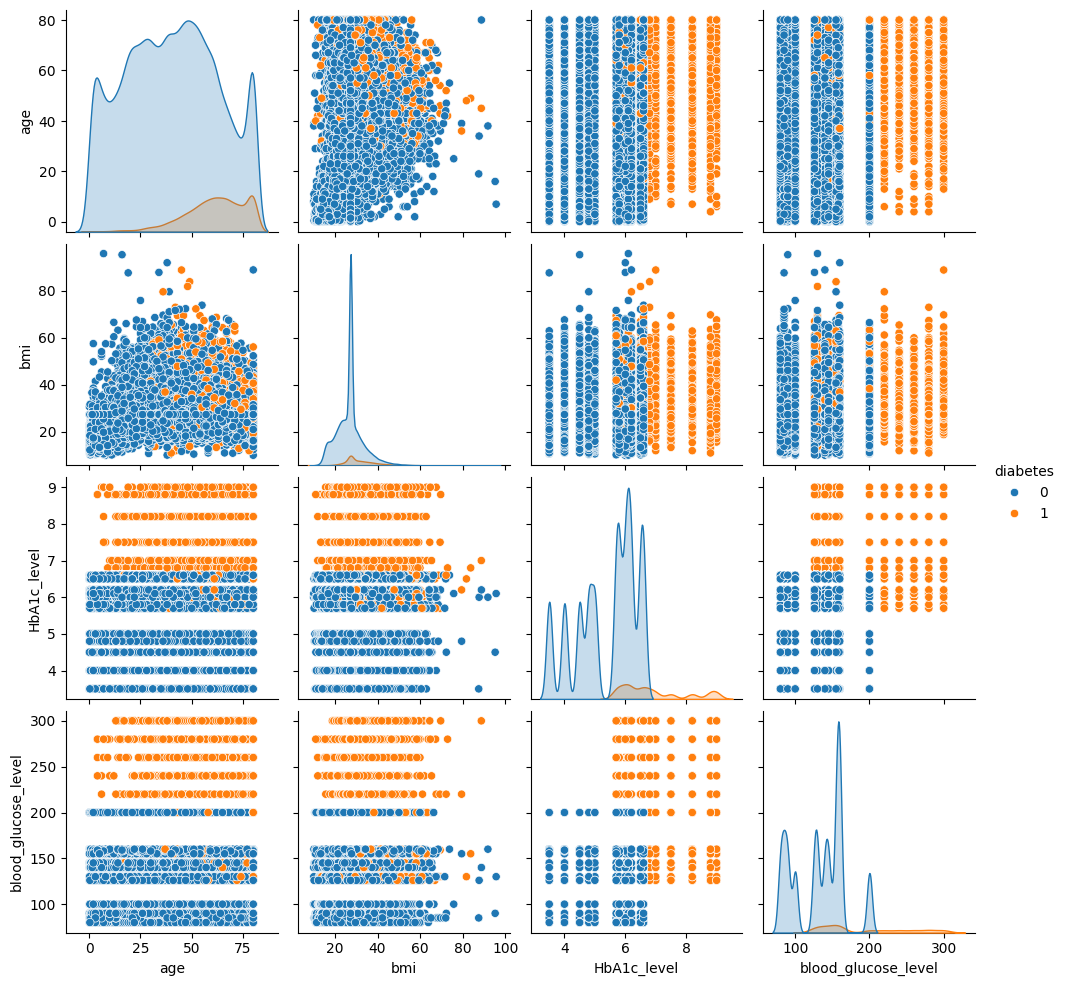

In [18]:
sns.pairplot(
    df[['age',
        'bmi',
        'HbA1c_level',
        'blood_glucose_level',
        'diabetes']],
    hue='diabetes'
)